In [1]:
### building first, simple CNN baseline for protein stability prediction based on wt & mut seq ###

In [2]:
### 1. imports


# basic functionality
import os 
import numpy as np
import pandas as pd
import scipy
import sklearn.metrics as skmetrics

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import lightning as L

import torchmetrics
from torchmetrics.regression import PearsonCorrCoef

In [3]:
### running on gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
### 2. Dataloading ###

aa_alphabet = 'ACDEFGHIKLMNPQRSTVWY' # amino acid alphabet
aa_to_int = {aa: i for i, aa in enumerate(aa_alphabet)} # mapping from amino acid to number

# function to one hot encode sequence
def one_hot_encode(sequence):
    # initialize a zero matrix of shape (len(sequence), len(amino_acids))
    one_hot = torch.zeros(len(sequence), len(aa_alphabet))
    for i, aa in enumerate(sequence):
        # set the column corresponding to the amino acid to 1
        one_hot[i].scatter_(0, torch.tensor([aa_to_int[aa]]), 1)
    return one_hot



# sequence data, comes already batched, so treat accordingly in dataloader (batch_size=1)
class SequenceData(Dataset):
    def __init__(self, csv_file, label_col="ddG_ML"):
        """
        Initializes the dataset. 
        input:
            csv_file: path to the relevant data file, eg. "/home/data/mega_train.csv"
        """
        self.df = pd.read_csv(csv_file, sep=",")
        self.label_col = label_col
        # only have mutation rows
        self.df = self.df[self.df.mut_type!="wt"]
        # process the mutation row
        self.df["mutation_pos"] = self.df["mut_type"].apply(lambda x: int(x[1:-1])-1) # make position start at zero
        self.df["mutation_to"] = self.df["mut_type"].apply(lambda x: aa_to_int[x[-1]]) # give numerical label to mutation

        # group by wild type
        self.df = self.df.groupby("WT_name").agg(list)
        # get wild type names
        self.wt_names = self.df.index.values
        # precompute one-hot encoding for faster training
        self.encoded_seqs = {}
        for wt_name in self.wt_names:
            # get the correct row
            mut_row = self.df.loc[wt_name]
            seq = mut_row["wt_seq"][0]
            self.encoded_seqs[wt_name] = one_hot_encode(seq)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get the wild type name
        wt_name = self.wt_names[idx]
        # get the correct row
        mut_row = self.df.loc[wt_name]
        # get the wt sequence in one hot encoding
        sequence_encoding = self.encoded_seqs[wt_name]
            # dimensions (len, 20)

        # create mask and target tensors
        mask = torch.zeros((1, len(sequence_encoding),20)) # will be 1 where we have a measurement 
        target = torch.zeros((1, len(sequence_encoding),20)) # ddg values
            # remember batch size = 1
        # all mutations from df
        positions = torch.tensor(mut_row["mutation_pos"])
        amino_acids = torch.tensor(mut_row["mutation_to"])
        # get the labels
        labels = torch.tensor(mut_row[self.label_col])

        for i in range(len(sequence_encoding)):
            mask[0,i,amino_acids[positions==i]] = 1 # one where we have data (i.e. ddG measurement)
            target[0,i,amino_acids[positions==i]] = labels[positions==i] # fill with ddG values
        
        # returns encoded sequence, mask and target sequence 
        return {"sequence": sequence_encoding[None,:,:].float(), "mask": mask, "labels": target}


        # use this structure to
        # - predict ddG for all possible mutations
        # - mask serves to only compute loss at positions where experimental data exists

In [5]:
# usage
dataset_train = SequenceData('mega_train.csv')
dataset_val= SequenceData('mega_val.csv')
# dataset_test = SequenceData('project_data/mega_test.csv') # only once available

# use batch_size=1 bc we treat each sequence as one batch
dataloader_val = DataLoader(dataset_val, batch_size=1, shuffle=False)
dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
# dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

In [6]:
### 3. Data exploration ###

print('training data')
print(type(dataset_train))
# custom Pytorch Dataset object

print(len(dataset_train))
# nb of proteins

exemplary_protein = dataset_train[0]
print('exemplary datapoint (wt protein 0), which will be fed into CNN as one input:')
print(type(exemplary_protein))

print({k: v.shape for k,v in exemplary_protein.items()})
    # IMPORTANT: only 'sequence' will be used for model training, 'mask' and 'labels' both serve loss computation


print('\nvalidation data')
print(type(dataset_val))
# custom Pytorch Dataset object

print(len(dataset_val))
# nb of proteins

exemplary_protein = dataset_val[0]
print('exemplary datapoint (wt protein 0), which will be fed into CNN as one input:')
print(type(exemplary_protein))

print({k: v.shape for k,v in exemplary_protein.items()})
    # IMPORTANT: only 'sequence' will be used for model training, 'mask' and 'labels' both serve loss computation


training data
<class '__main__.SequenceData'>
239
exemplary datapoint (wt protein 0), which will be fed into CNN as one input:
<class 'dict'>
{'sequence': torch.Size([1, 63, 20]), 'mask': torch.Size([1, 63, 20]), 'labels': torch.Size([1, 63, 20])}

validation data
<class '__main__.SequenceData'>
31
exemplary datapoint (wt protein 0), which will be fed into CNN as one input:
<class 'dict'>
{'sequence': torch.Size([1, 39, 20]), 'mask': torch.Size([1, 39, 20]), 'labels': torch.Size([1, 39, 20])}


In [7]:
print(dataloader_train)

print(type(dataset_train))

<class '__main__.SequenceData'>


In [8]:
### 4. define CNN model architecture ###

# create new model class that inherits all properties from the torch.nn.Module
class simplecnn(nn.Module):
    # initialize
    def __init__(self):
        # load parent module
        super(simplecnn, self).__init__()

        # ingredients
        self.conv1 = nn.Conv1d(in_channels=20, out_channels=128,kernel_size=11,padding=5)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=128,kernel_size=7,padding=3)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=64,kernel_size=5,padding=2)
        self.convlinear = nn.Conv1d(in_channels=64, out_channels=64,kernel_size=1)
        self.output = nn.Conv1d(in_channels=64, out_channels=20,kernel_size=1)

        # recipe
    def forward(self, x):
        
        x = x.squeeze(0) # goal: 1x1xlen(seq)x20 --> 1xlen(seq)x20
        x = x.permute(0,2,1) # permute dimensions from 1x20xlen(seq) to 20x1x63 (needed for proper kernel convolutoin)

        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        x = F.relu(self.convlinear(x))
        x = self.output(x)
        

        x = x.permute (0,2,1) # permute dimensions back to 1xlen(seq)x20
        

        return x
        

In [9]:
### 5. wrap model into lightning for training ###

class Litsimplecnn(L.LightningModule):
    def __init__(self, learning_rate):
        super().__init__()
        #self.save_hyperparameters()
        
        #self.model = simplecnn(hidden=hidden)
        self.model = simplecnn()
        self.lr = learning_rate

        self.loss_function = nn.MSELoss()
        #self.loss_function = nn.SmoothL1Loss(beta=1.0)
        self.mae = torchmetrics.MeanAbsoluteError() # accuracy only suited for classification (discrete outcome variable)
        #track different accuracy and mae,... metrics here

    def onlyrelevantddG(self, batch):
        '''
        returns: pred_ddg: predicted ddG for the mutation in each sample; y: true experimental ddG
        '''
        x = batch["sequence"] # --> torch.Size([1, 1, 39, 20])
        
        
        mask = batch["mask"]# --> torch.Size([1, 1, 39, 20])
    
        
        true_ddG = batch["labels"] # --> torch.Size([1, 1, 39, 20])
        true_ddG = true_ddG[mask==1] ### --> ERROR HAPPENS HERE: true_ddG is flattened to vector of size 686 !!! (instead of same dimensions as input)
        
        pred_all = self.model(x)

        pred_ddG = pred_all[mask.squeeze(0)==1]
        #true_ddG = true_ddG[mask==1]
        '''
        preds =[]
        all_y = []

        preds.append(prediction[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
        all_y.append(target[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
        '''

        return pred_ddG, true_ddG

        
        
    def training_step(self, batch, batch_idx):
        
        pred_ddG, true_ddG = self.onlyrelevantddG(batch)

        loss = self.loss_function(pred_ddG, true_ddG)
        mae = self.mae(pred_ddG, true_ddG)

        self.log("train loss:", loss, on_epoch=True, prog_bar=True)
        self.log("train mae:", mae, on_epoch=True, prog_bar=True)
        
        return loss



    def validation_step (self, batch, batch_idx):

        pred_ddG, true_ddG = self.onlyrelevantddG(batch)
        
        loss = self.loss_function(pred_ddG, true_ddG)
        
        mae = self.mae(pred_ddG, true_ddG)
        

        self.log("val loss:", loss, on_epoch=True, prog_bar=True)
        self.log("val mae:", mae, on_epoch=True, prog_bar=True)

        return loss

        

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, betas = (0.9,0.99), eps = 1e-8,weight_decay=0.01)
        


In [10]:
### create a tensorboard session ###
# new tab should open in your browser
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/

In [11]:
### 6. train model ###


# initialize model (always needed to have a new model for training)
lightning_model = Litsimplecnn(learning_rate=1e-4)


# instantiate lightning trainer
trainer = L.Trainer(max_epochs=25, log_every_n_steps=1)


# train
trainer.fit(lightning_model, dataloader_train, dataloader_val)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type              | Params | Mode  | FLOPs
---------------

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=25` reached.


RMSE: 0.5525423884391785
Pearson r: PearsonRResult(statistic=0.59974235, pvalue=0.0)
Spearman r: SignificanceResult(statistic=0.563756641734006, pvalue=0.0)


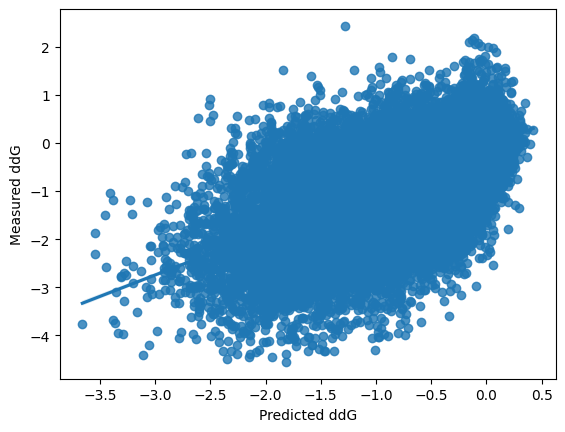

In [12]:
preds =[]
all_y = []

for batch in dataloader_val:
    # read from batch
    x = batch["sequence"]#[0]
    mask = batch["mask"]#[0] #instead of squeezing later
    target = batch["labels"]#[0]
    ## adjust to work with your model
    # predict
    prediction = lightning_model.model(x)
    preds.append(prediction[mask.squeeze(0)==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
    all_y.append(target[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence

# concatenate and plot
preds= np.concatenate(preds)
all_y = np.concatenate(all_y)

sns.regplot(x=preds,y=all_y)
plt.xlabel("Predicted ddG")
plt.ylabel("Measured ddG")

# get RMSE, Pearson and Spearman correlation 
print("RMSE:", skmetrics.mean_squared_error(all_y, preds))
print("Pearson r:", scipy.stats.pearsonr(preds, all_y))
print("Spearman r:", scipy.stats.spearmanr(preds, all_y))

In [25]:
### 7. feed single sequence into model visualize output tensor ###

model = lightning_model.model  # extract pure CNN
model.eval()
model.to(device)

# prepare input
sequence = "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"  # example sequence #maybe use SequenceData

encoded = one_hot_encode(sequence)        # (L, 20)
encoded = encoded[None, :, :]             # (1, L, 20)
encoded = encoded[None, :, :, :]          # (1, 1, L, 20)  <-- match training input
encoded = encoded.float().to(device)
# get model output
with torch.no_grad():
    output = model(encoded)
print(output.shape)
# torch.Size([1, L, 20])
ddg_matrix = output[0].cpu().numpy() # shape (L, 20), what position is what?
# visualize ddG matrix

torch.Size([1, 76, 20])


In [45]:
ddg_matrix
ddg_matrix[1,9]

-0.18747899

In [35]:
def mutation_dict(sequence, ddg_matrix):
    results = {}
    for i, wt_aa in enumerate(sequence):
        for j in range(20):
            mut_aa = aa_alphabet[j]
            #if mut_aa != wt_aa: # if uncommenting the if statement: need to indent below line
            results[f"{wt_aa}{i+1}{mut_aa}"] = ddg_matrix[i, j].item()
    return results

x = mutation_dict(sequence, ddg_matrix)

len(x)

1520

In [37]:
position = 10
aa_index = aa_to_int["A"]

predicted_ddg = output[0, position, aa_index].item()

print("Predicted ΔΔG:", predicted_ddg)

Predicted ΔΔG: -0.11978758871555328


In [46]:
wt_sequence = "MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFVRDFAGDGLFTSWTHEKNWKKAHNILLPSFSQQAMKGYHAMMVDIAVQLVQKWERLNADEHIEVPEDMTRLTLDTIGLCGFNYRFNSFYRDQPHPFITSMVRALDEAMNKLQRANPDDPAYDENKRQFQEDIKVMNDLVDKIIADRKASGEQSDDLLTHMLNGKDPETGEPLDDENIRYQIITFLIAGHETTSGLLSFALYFLVKNPHVLQKAAEEAARVLVDPVPSYKQVKQLKYVGMVLNEALRLWPTAPAFSLYAKEDTVLGGEYPLEKGDELMVLIPQLHRDKTIWGDDVEEFRPERFENPSAIPQHAFKPFGNGQRACIGQQFALHEATLVLGMMLKHFDFEDHTNYELDIKETLTLKPEGFVVKAKSKKIPLGGIPSPSTEQSAKKVRKKAENAHNTPLLVLYGSNMGTAEGTARDLADIAMSKGFAPQVATLDSHAGNLPREGAVLIVTASYNGHPPDNAKQFVDWLDQASADEVKGVRYSVFGCGDKNWATTYQKVPAFIDETLAAKGAENIADRGEADASDDFEGTYEEWREHMWSDVAAYFNLDIENSEDNKSTLSLQFVDSAADMPLAKMHGAFSTNVVASKELQQPGSARSTRHLEIELPKEASYQEGDHLGVIPRNYEGIVNRVTARFGLDASQQIRLEAEEEKLAHLPLAKTVSVEELLQYVELQDPVTRTQLRAMAAKTVCPPHKVELEALLEKQAYKEQVLAKRLTMLELLEKYPACEMKFSEFIALLPSIRPRYYSISSSPRVDEKQASITVSVVSGEAWSGYGEYKGIASNYLAELQEGDTITCFISTPQSEFTLPKDPETPLIMVGPGTGVAPFRGFVQARKQLKEQGQSLGEAHLYFGCRSPHEDYLYQEELENAQSEGIITLHTAFSRMPNQPKTYVQHVMEQDGKKLIELLDQGAHFYICGDGSQMAPAVEATLMKSYADVHQVSEADARLWLQQLEEKGRYAKDVWAG"

In [63]:
wt_sequence[78]

'V'

In [67]:
def apply_mutation_step(sequence, mutations, shift=1, validate_wt=False):
    seq_list = list(sequence)
    
    if validate_wt:
        for mutation in mutations:
            wt_aa = mutation[0]
            pos = int(mutation[1:-1]) - 1 + shift
            if seq_list[pos] != wt_aa:
                raise ValueError(
                    f"Mismatch at position {pos+1}: expected {seq_list[pos]}, got {wt_aa}"
                )
    
    # Apply all mutations
    for mutation in mutations:
        mut_aa = mutation[-1]
        pos = int(mutation[1:-1]) - 1 + shift
        seq_list[pos] = mut_aa
    
    return "".join(seq_list)


def build_mutation_trajectory(wt_sequence, mutation_steps, shift=1):
    """
    Apply a list of mutation steps sequentially and save all intermediates.
    
    Returns: list of sequences [WT, step1_seq, step2_seq, ..., final_seq]
    """
    sequences = [wt_sequence]
    current_seq = wt_sequence
    
    for step in mutation_steps:
        current_seq = apply_mutation_step(current_seq, step, shift=shift)
        sequences.append(current_seq)
    
    return sequences

In [83]:
mutation_steps = [
    ["V78A", "H138Y", "T175I", "V178I", "A184V", "H236Q", "E252G", "R255S", "A290V", "A295T", "L353V"],
    ["Y138H", "I178V", "F205C", "S226R", "T295A"],
    ["R47C", "A78F", "A82S", "K94I", "P142S", "A328F"],
    ["L52I", "I366V"],
    ["L188P"],
    ["A74S"],
    ["V184A"],
    ["A74E", "S82G", "A184V", "G443A"]
]

trajectory = build_mutation_trajectory(wt_sequence, mutation_steps, shift=1)

# Print first few steps to verify
print("WT:", trajectory[0][:80], "...")
print("After step 1:", trajectory[1][:80], "...")
print("After step 2:", trajectory[2][:80], "...")
print("After step 3:", trajectory[3][:80], "...")
print("Total sequences saved:", len(trajectory))

WT: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFVR ...
After step 1: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFAR ...
After step 2: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGRVTRYLSSQRLIKEACDESRFDKNLSQALKFAR ...
After step 3: MTIKEMPQPKTFGELKNLPLLNTDKPVQALMKIADELGEIFKFEAPGCVTRYLSSQRLIKEACDESRFDKNLSQALKFFR ...
Total sequences saved: 9


In [84]:
print(trajectory[7][82])
print(trajectory[8][82])

S
G


In [120]:
def apply_single_mutation(sequence, mutation, shift=1):
    """
    Apply a single mutation to a protein sequence.
    
    Parameters:
        sequence : str
            The current protein sequence.
        mutation : str
            Mutation in format "A74S" (original AA, position 1-based, new AA).
        shift : int, optional
            Offset to adjust mutation numbering (default 0).

    Returns:
        str : the mutated sequence
    """
    seq_list = list(sequence)
    
    wt_aa = mutation[0]
    mut_aa = mutation[-1]
    pos = int(mutation[1:-1]) - 1 + shift  # convert to 0-based index
    
    # Optional validation: check that current residue matches expected WT
    if seq_list[pos] != wt_aa:
        raise ValueError(
            f"Mismatch at position {pos+1}: expected {seq_list[pos]}, got {wt_aa}"
        )
    
    # Apply mutation
    seq_list[pos] = mut_aa
    
    return "".join(seq_list)

import torch

def predict_ddg_for_mutation(sequence, mutation, model, device, aa_to_int, shift=1):
    """
    Predict ΔΔG for a single mutation on a given sequence using a CNN.
    
    Parameters:
        sequence : str
            The protein sequence (WT or already mutated).
        mutation : str
            Mutation string like "A74S".
        model : torch.nn.Module
            Trained CNN model (pure model, not Lightning wrapper).
        device : torch.device
            e.g., torch.device('cuda') or torch.device('cpu')
        aa_to_int : dict
            Mapping of amino acid letters to indices (0-19)
        shift : int
            Position shift if mutation numbering is offset from 1 (default 1)
    
    Returns:
        float : predicted ΔΔG for this mutation
    """
    model.eval()
    
    # --- Encode sequence ---
    encoded = one_hot_encode(sequence)           # (L, 20)
    encoded = encoded[None, :, :] # (1, L, 20)
    encoded = encoded[None, :, :, :].float().to(device)
    # --- Forward pass through CNN ---
    with torch.no_grad():
        output = model(encoded)  # shape: (1, L, 20)
    
    ddg_matrix = output[0].cpu().numpy()  # (L, 20)
    
    # --- Extract mutation info ---
    pos = int(mutation[1:-1])
    mut_aa = mutation[-1]
    aa_idx = aa_to_int[mut_aa]
    
    ddg_val = ddg_matrix[pos, aa_idx]
    return ddg_val

In [121]:
zy = apply_single_mutation(wt_sequence,mutation_steps[0][0], shift=1)
print(wt_sequence[78])
print(zy[78])

V
A


In [122]:
### 7. feed single sequence into model visualize output tensor ###

model = lightning_model.model  # extract pure CNN
model.eval()
model.to(device)

# prepare input
sequence = trajectory[4]  # example sequence #maybe use SequenceData

encoded = one_hot_encode(sequence)        # (L, 20)
encoded = encoded[None, :, :]             # (1, L, 20)
encoded = encoded[None, :, :, :]          # (1, 1, L, 20)  <-- match training input
encoded = encoded.float().to(device)
# get model output
with torch.no_grad():
    output = model(encoded)
print(output.shape)
# torch.Size([1, L, 20])
ddg_matrix = output[0].cpu().numpy() # shape (L, 20), what position is what?
# visualize ddG matrix
mutation = "L188P"
pos = int(mutation[1:-1])    # convert 1-based to 0-based index 
mut_aa = mutation[-1]
aa_idx = aa_to_int[mut_aa]

ddg_value = ddg_matrix[pos, aa_idx]
print(f"Predicted ΔΔG for {mutation}: {ddg_value:.3f}")

print(ddg_matrix[188, 12])
print(trajectory[5][188])
zxy=predict_ddg_for_mutation(trajectory[4],mutation_steps[4][0], model, device, aa_to_int)
print(zxy)

torch.Size([1, 1049, 20])
Predicted ΔΔG for L188P: -2.380
-2.380309
P
-2.380309


In [ ]:
##################################################################################################################

In [125]:
def get_ddg_matrices_for_trajectory(trajectory, model, device):
    """
    Compute the full ΔΔG matrix (all positions × all amino acids) for every sequence in trajectory.
    
    Parameters:
        trajectory : list of str
            List of sequences (WT + intermediate sequences)
        model : torch.nn.Module
            Trained CNN
        device : torch.device
    
    Returns:
        list of np.ndarray
            Each element is a matrix of shape (L, 20) for that sequence
    """
    model.eval()
    ddg_matrices = []
    
    for seq in trajectory:
        # Encode sequence
        encoded = one_hot_encode(seq)  # (1, L, 20)
        encoded = encoded[None, :, :]  # (1, L, 20)
        encoded = encoded[None, :, :, :].float().to(device)  # (1, L, 20)
        
        with torch.no_grad():
            output = model(encoded)  # (1, L, 20)
        
        ddg_matrix = output[0].cpu().numpy()  # shape (L, 20)
        ddg_matrices.append(ddg_matrix)
    
    return ddg_matrices

In [129]:
ddg_matrices = get_ddg_matrices_for_trajectory(trajectory, model, device)
#print(ddg_matrices)

In [138]:
step_ddg = []
for step_idx, step_mutations in enumerate(mutation_steps):
    ddg_matrix = ddg_matrices[step_idx]  # sequence after previous step
    step_dict = {}
    for mut in step_mutations:
        pos = int(mut[1:-1])
        aa_idx = aa_to_int[mut[-1]]
        step_dict[mut] = ddg_matrix[pos, aa_idx]
    step_ddg.append(step_dict)

In [139]:
print(step_ddg)
print(step_ddg[4])

[{'V78A': -1.5620152, 'H138Y': -0.12108158, 'T175I': -0.22466668, 'V178I': -0.30465788, 'A184V': -0.75998247, 'H236Q': -0.2301048, 'E252G': -0.49957952, 'R255S': -0.58482784, 'A290V': -0.65899795, 'A295T': -1.5142136, 'L353V': -1.0251162}, {'Y138H': -1.4361486, 'I178V': -0.6749579, 'F205C': -0.8479315, 'S226R': -0.23723315, 'T295A': -0.8176761}, {'R47C': -0.14488402, 'A78F': -0.95638406, 'A82S': -0.6902142, 'K94I': -0.043996565, 'P142S': -0.25298154, 'A328F': -0.33911213}, {'L52I': -0.63650894, 'I366V': -0.683928}, {'L188P': -2.380309}, {'A74S': -1.039837}, {'V184A': -0.9626865}, {'A74E': -0.5942395, 'S82G': -0.878897, 'A184V': -0.717059, 'G443A': -1.4502996}]
{'L188P': -2.380309}


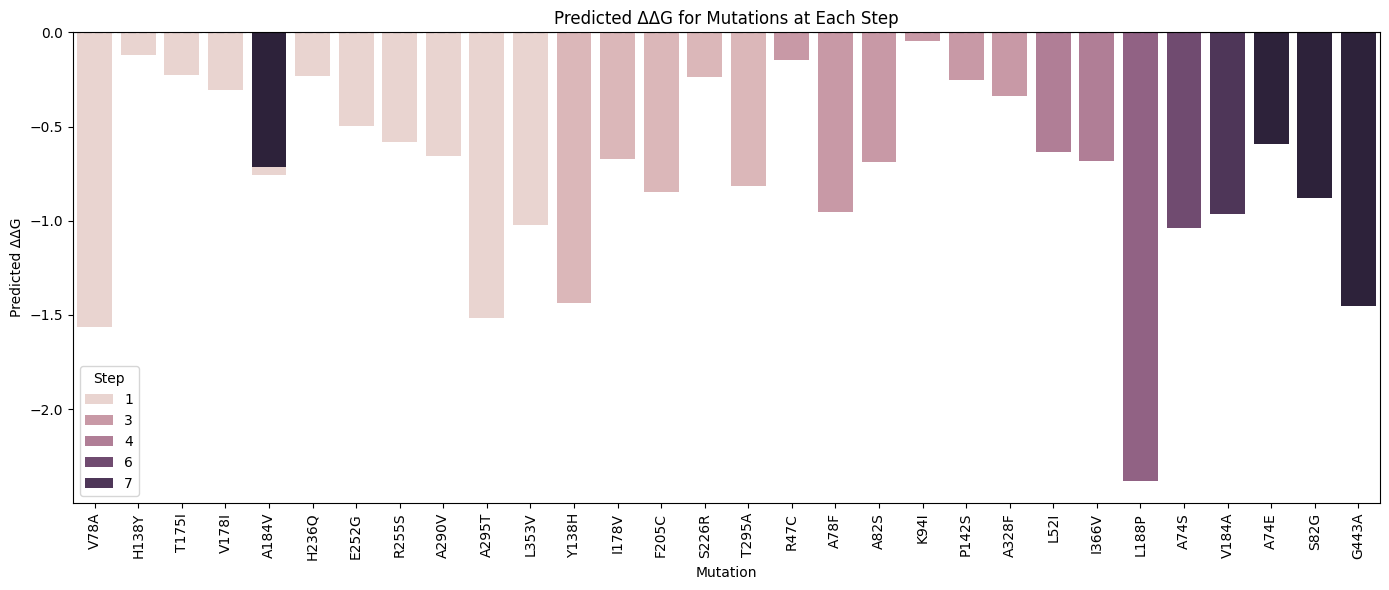

In [140]:
#Illustration:
rows = []
for step_idx, step_dict in enumerate(step_ddg):
    for mut, ddg in step_dict.items():
        rows.append({"Step": step_idx+1, "Mutation": mut, "ddG": ddg})

df = pd.DataFrame(rows)

plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Mutation", y="ddG", hue="Step", dodge=False)
plt.xticks(rotation=90)
plt.axhline(0, color='black', linestyle='--')  # zero reference
plt.ylabel("Predicted ΔΔG")
plt.title("Predicted ΔΔG for Mutations at Each Step")
plt.legend(title="Step")
plt.tight_layout()
plt.show()

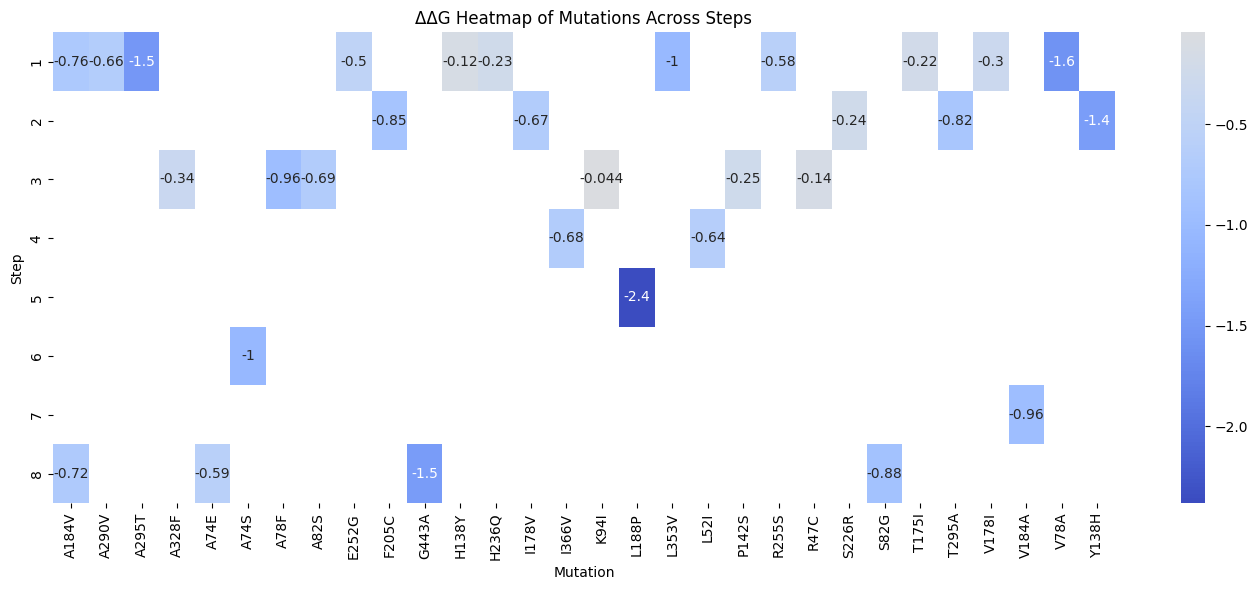

In [141]:
# Pivot table: steps as rows, mutations as columns
pivot = df.pivot(index="Step", columns="Mutation", values="ddG")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0)
plt.title("ΔΔG Heatmap of Mutations Across Steps")
plt.ylabel("Step")
plt.xlabel("Mutation")
plt.tight_layout()
plt.show()